# Analiza podatkov s pandas

Analiza znamenitosti, zaščitenih z Unescom, je zgrajena iz 6 delov: po kategorijah, državah, kontinentih, letu vpisa, površini in kriterijih.

In [1]:
import pandas as pd
import ast

pd.options.display.max_rows = 10

tabela = pd.read_csv('podatki/podatki.csv', index_col='id')

In [2]:
tabela

,znamenitost,kategorija,drzave,kontinenti,leto vpisa,povrsina [ha],kriteriji
id,,,,,,,
211,Minaret and Archaeological Remains of Jam,cultural_danger,['Afghanistan'],['Asia'],2002,70,"[('ii', 'to exhibit an important interchange o..."
208,Cultural Landscape and Archaeological Remains ...,cultural_danger,['Afghanistan'],['Asia'],2003,158.9265,"[('i', 'to represent a masterpiece of human cr..."
99,Natural and Cultural Heritage of the Ohrid region,mixed,"['Albania', 'North Macedonia']",['Europe'],1979,94728.6,"[('i', 'to represent a masterpiece of human cr..."
570,Butrint,cultural,['Albania'],['Europe'],1992,ni podatka,"[('iii', 'to bear a unique or at least excepti..."
569,Historic Centres of Berat and Gjirokastra,cultural,['Albania'],['Europe'],2005,58.9,"[('iii', 'to bear a unique or at least excepti..."
...,...,...,...,...,...,...,...
509,Mosi-oa-Tunya / Victoria Falls,natural,"['Zambia', 'Zimbabwe']",['Africa'],1989,6860,"[('vii', 'to contain superlative natural pheno..."
302,"Mana Pools National Park, Sapi and Chewore Saf...",natural,['Zimbabwe'],['Africa'],1984,676600,"[('vii', 'to contain superlative natural pheno..."
364,Great Zimbabwe National Monument,cultural,['Zimbabwe'],['Africa'],1986,722,"[('i', 'to represent a masterpiece of human cr..."


Vidimo, da je zajetih vseh 1248 znamenitosti z Unescovega seznama in da je poleg imen še 6 stolpcev drugih podatkov o znamenitostih.

In [3]:
for element in ['drzave', 'kontinenti', 'kriteriji']:
    tabela[element] = tabela[element].apply(ast.literal_eval)

## 1. Analiza po kategorijah

In [4]:
tabela1 = tabela.groupby("kategorija")["znamenitost"].count().sort_values(ascending=False)
tabela1

kategorija
cultural           933
natural            221
mixed               41
cultural_danger     39
natural_danger      14
Name: znamenitost, dtype: int64

Največ (okoli tri četrtine) znamenitosti je kulturnih, sledijo naravne, najmanj pa je mešanih in ogroženih.

Deleže lahko ponazorimo tudi s krožnim diagramom.

<Axes: title={'center': 'znamenitosti po kategorijah'}, ylabel='znamenitost'>

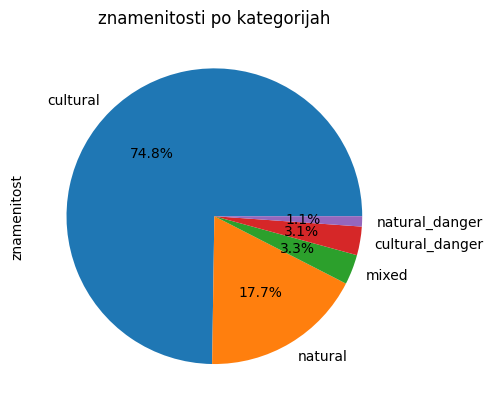

In [5]:
tabela1.plot.pie(autopct='%1.1f%%', title="znamenitosti po kategorijah")

## 2. Analiza po državah

Ker so države shranjene v seznamih, jih najprej ločimo, tako da bo podana le ena na vrstico.

In [6]:
tabela2 = tabela.explode('drzave')
tabela2

,znamenitost,kategorija,drzave,kontinenti,leto vpisa,povrsina [ha],kriteriji
id,,,,,,,
211,Minaret and Archaeological Remains of Jam,cultural_danger,Afghanistan,[Asia],2002,70,"[(ii, to exhibit an important interchange of h..."
208,Cultural Landscape and Archaeological Remains ...,cultural_danger,Afghanistan,[Asia],2003,158.9265,"[(i, to represent a masterpiece of human creat..."
99,Natural and Cultural Heritage of the Ohrid region,mixed,Albania,[Europe],1979,94728.6,"[(i, to represent a masterpiece of human creat..."
99,Natural and Cultural Heritage of the Ohrid region,mixed,North Macedonia,[Europe],1979,94728.6,"[(i, to represent a masterpiece of human creat..."
570,Butrint,cultural,Albania,[Europe],1992,ni podatka,"[(iii, to bear a unique or at least exceptiona..."
...,...,...,...,...,...,...,...
509,Mosi-oa-Tunya / Victoria Falls,natural,Zimbabwe,[Africa],1989,6860,"[(vii, to contain superlative natural phenomen..."
302,"Mana Pools National Park, Sapi and Chewore Saf...",natural,Zimbabwe,[Africa],1984,676600,"[(vii, to contain superlative natural phenomen..."
364,Great Zimbabwe National Monument,cultural,Zimbabwe,[Africa],1986,722,"[(i, to represent a masterpiece of human creat..."


Sedaj lahko preštejemo, koliko znamenitosti ima posamezna država, in jih uredimo padajoče.

In [7]:
tabela2.groupby('drzave')['znamenitost'].count().sort_values(ascending=False)

drzave
Italy              61
China              60
Germany            55
France             54
Spain              50
                   ..
Solomon Islands     1
Togo                1
Vanuatu             1
Zambia              1
ni podatka          1
Name: znamenitost, Length: 171, dtype: int64

Največ znamenitosti ima Italija, sledi Kitajska, nato pa še ostale večje evropske države. Vse imajo dolgo in bogato zgodovino ter so velike po površini, zato so podatki smiselni. Najmanj znamenitosti imajo najmanjše države, kar je tudi pričakovano.

Podobno lahko naredimo tudi za znamenitosti posamezne kategorije.

In [8]:
tabela2[tabela2.kategorija == "cultural"].groupby("drzave")["znamenitost"].count().sort_values(ascending=False)

drzave
Italy                                 55
Germany                               52
France                                45
Spain                                 44
China                                 41
                                      ..
Singapore                              1
Uganda                                 1
Togo                                   1
Venezuela (Bolivarian Republic of)     1
Vanuatu                                1
Name: znamenitost, Length: 146, dtype: int64

Največ kulturnih znamenitosti ima Italija, sledijo Nemčija, Francija, Španija, nato Kitajska itn. Najmanj pa manjše države.

In [9]:
tabela2[tabela2.kategorija == "natural"].groupby("drzave")["znamenitost"].count().sort_values(ascending=False)

drzave
China                                 15
Australia                             12
Canada                                11
Russian Federation                    11
United States of America              11
                                      ..
Turkmenistan                           1
Ukraine                                1
Venezuela (Bolivarian Republic of)     1
Yemen                                  1
Zambia                                 1
Name: znamenitost, Length: 105, dtype: int64

Največ naravnih znamenitosti ima Kitajska, sledi Avstralija, nato pa še ostale največje države na svetu, kar je pričakovano, najmanj pa najmanjše države oz. tiste z manj raznolikim reliefom.

In [10]:
tabela2[tabela2.kategorija == "mixed"].groupby("drzave")["znamenitost"].count().sort_values(ascending=False)

drzave
Australia                                               4
China                                                   4
Greece                                                  2
France                                                  2
Spain                                                   2
                                                       ..
Sweden                                                  1
United Kingdom of Great Britain and Northern Ireland    1
United Republic of Tanzania                             1
United States of America                                1
Viet Nam                                                1
Name: znamenitost, Length: 32, dtype: int64

Največ mešanih znamenitosti imata Avstralija in Kitajska; obe veliki državi.

In [11]:
tabela2[tabela2.kategorija.str.contains("danger")].groupby("drzave")["znamenitost"].count().sort_values(ascending=False).head(10)

drzave
Syrian Arab Republic                6
Libya                               4
Democratic Republic of the Congo    4
Yemen                               4
State of Palestine                  3
Mali                                3
Iraq                                3
Ukraine                             3
Afghanistan                         2
Central African Republic            1
Name: znamenitost, dtype: int64

Vidimo, da se ogrožene znamenitosti nahajajo na območjih nemirov ali celo vojne. Največ jih je v Siriji.

Naredimo lahko tudi funkcijo za pregled števila znamenitosti, urejenih po kategoriji, za poljubno državo. Kot primer lahko vzamemo Slovenijo:

In [12]:
def pregled_po_drzavi(drzava):
    return tabela2[tabela2.drzave == drzava].groupby("kategorija")["kategorija"].count()

pregled_po_drzavi('Slovenia')

kategorija
cultural    3
natural     2
Name: kategorija, dtype: int64

Slovenija ima torej 3 kulturne znamenitosti in 2 naravni.

Nekatere znamenitosti lahko najdemo v več državah, zato jih lahko uredimo tudi po številu držav, ki jim pripadajo.

In [13]:
tabela2.groupby("znamenitost")["drzave"].count().sort_values(ascending=False).head(10)

znamenitost
Ancient and Primeval Beech Forests of the Carpathians and Other Regions of Europe             18
Struve Geodetic Arc                                                                           10
The Great Spa Towns of Europe                                                                  7
The Architectural Work of Le Corbusier, an Outstanding Contribution to the Modern Movement     7
Qhapaq Ñan, Andean Road System                                                                 6
Prehistoric Pile Dwellings around the Alps                                                     6
Moravian Church Settlements                                                                    4
Stećci Medieval Tombstone Graveyards                                                           4
Silk Roads: the Routes Network of Chang'an-Tianshan Corridor                                   3
Sangha Trinational                                                                             3
Name: drzave, dtyp

Vidimo, da so starodavni prvobitni bukovi gozdovi Karpatov in drugih delov Evrope zaščiteni v največ (kar osemnajstih) državah. Sledi Struvejev geodetski lok, zaščiten v desetih državah.

## 3. Analiza po kontinentih

Kontinenti so prav tako shranjeni v seznamih, zato jih najprej ločimo, da bo podan le eden na vrstico.

In [14]:
tabela3 = tabela.explode("kontinenti")
tabela3

,znamenitost,kategorija,drzave,kontinenti,leto vpisa,povrsina [ha],kriteriji
id,,,,,,,
211,Minaret and Archaeological Remains of Jam,cultural_danger,[Afghanistan],Asia,2002,70,"[(ii, to exhibit an important interchange of h..."
208,Cultural Landscape and Archaeological Remains ...,cultural_danger,[Afghanistan],Asia,2003,158.9265,"[(i, to represent a masterpiece of human creat..."
99,Natural and Cultural Heritage of the Ohrid region,mixed,"[Albania, North Macedonia]",Europe,1979,94728.6,"[(i, to represent a masterpiece of human creat..."
570,Butrint,cultural,[Albania],Europe,1992,ni podatka,"[(iii, to bear a unique or at least exceptiona..."
569,Historic Centres of Berat and Gjirokastra,cultural,[Albania],Europe,2005,58.9,"[(iii, to bear a unique or at least exceptiona..."
...,...,...,...,...,...,...,...
509,Mosi-oa-Tunya / Victoria Falls,natural,"[Zambia, Zimbabwe]",Africa,1989,6860,"[(vii, to contain superlative natural phenomen..."
302,"Mana Pools National Park, Sapi and Chewore Saf...",natural,[Zimbabwe],Africa,1984,676600,"[(vii, to contain superlative natural phenomen..."
364,Great Zimbabwe National Monument,cultural,[Zimbabwe],Africa,1986,722,"[(i, to represent a masterpiece of human creat..."


Poglejmo, koliko znamenitosti najdemo na posameznem kontinentu.

In [15]:
tabela_3 = tabela3.groupby("kontinenti")["znamenitost"].count().sort_values(ascending=False)
tabela_3

kontinenti
Europe           492
Asia             374
Africa           154
North America    118
South America     82
Oceania           32
ni podatka         1
Name: znamenitost, dtype: int64

Največ znamenitosti je v Evropi, sledijo Azija, Afrika in Ameriki. Najmanj jih ima Oceanija.

Rezultate lahko prikažemo tudi s stolpičnim diagramom.

<Axes: title={'center': 'število znamenitosti po kontinentih'}, xlabel='kontinenti', ylabel='število'>

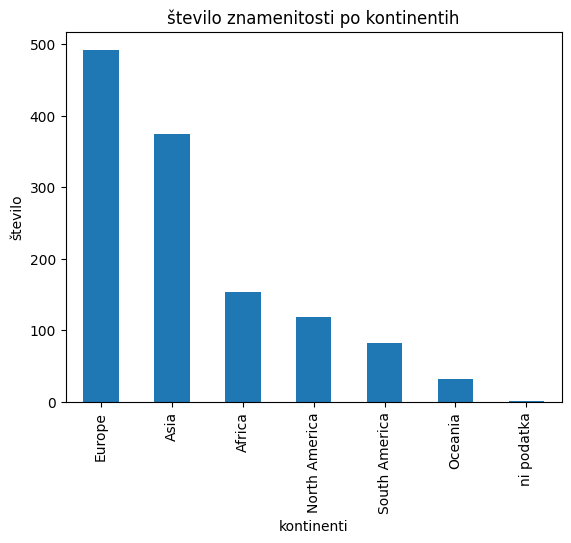

In [16]:
tabela_3.plot.bar(ylabel="število", title="število znamenitosti po kontinentih")

Ugotovimo lahko tudi, kateri kontinent ima največ znamenitosti po poljubni kategoriji.

In [17]:
tabela3[tabela3["kategorija"] == 'cultural'].groupby("kontinenti")["znamenitost"].count().sort_values(ascending=False)

kontinenti
Europe           426
Asia             283
Africa            93
North America     73
South America     52
Oceania            9
Name: znamenitost, dtype: int64

Največ kulturnih znamenitosti je v Evropi, sledi Azija; najmanj jih je v Oceaniji.

In [18]:
tabela3[tabela3["kategorija"] == 'natural'].groupby("kontinenti")["znamenitost"].count().sort_values(ascending=False)

kontinenti
Asia             59
Europe           52
Africa           39
North America    35
South America    23
Oceania          15
Name: znamenitost, dtype: int64

Največ naravnih znamenitosti ima Azija, sledi Evropa; najmanj jih ima Oceanija.

Nekaj znamenitosti je celo zaščitenih na več kontinentih.

In [19]:
tabela3.groupby("znamenitost")["kontinenti"].count().sort_values(ascending=False)

znamenitost
The Architectural Work of Le Corbusier, an Outstanding Contribution to the Modern Movement    3
Landscapes of Dauria                                                                          2
Moravian Church Settlements                                                                   2
Uvs Nuur Basin                                                                                2
Wooden <em>Tserkvas</em> of the Carpathian Region in Poland and Ukraine                       1
                                                                                             ..
Wet Tropics of Queensland                                                                     1
Whale Sanctuary of El Vizcaino                                                                1
White City of Tel-Aviv – the Modern Movement                                                  1
White Monuments of Vladimir and Suzdal                                                        1
Wieliczka and Bochnia Royal 

Le Corbusierova arhitekturna dela so zaščitena na največ, in sicer treh kontinentih. Sledijo še tri znamenitosti na dveh kontinentih.

## 4. Analiza po letu vpisa znamenitosti

In [20]:
tabela["leto vpisa"].sort_values()

id
26      1978
29      1978
32      1978
4       1978
3       1978
        ... 
1582    2025
1734    2025
1748    2025
1732    2025
1709    2025
Name: leto vpisa, Length: 1248, dtype: int64

Vidimo, da se znamenitosti dodaja na Unescov seznam vse od leta 1978 naprej do danes.

Ugotovimo lahko tudi, koliko jih je bilo dodanih vsako leto.

In [21]:
stevilo_vpisov = tabela.groupby("leto vpisa")["znamenitost"].count()
stevilo_vpisov

leto vpisa
1978    12
1979    45
1980    27
1981    26
1982    24
        ..
2019    29
2021    34
2023    45
2024    24
2025    26
Name: znamenitost, Length: 46, dtype: int64

Prvo leto je bilo na seznam dodanih relativno malo znamenitosti (12), leto pozneje pa že veliko več (45). Pozneje izgleda, da se število giblje med 20 in 30. Glede na to, da je bilo letos dodanih že 26 znamenitosti, se očitno število dodanih znamenitosti z leti ne niža.

In [22]:
x = stevilo_vpisov.mean()
print(f'{x:.2f}')

27.13


Povprečno število na seznam dodanih znamenitosti je malo več kot 27, kar bi pričakovali po prejšnji tabeli.

Za boljšo predstavo si lahko izrišemo tudi graf.

<Axes: title={'center': 'število vpisanih znamenitosti na leto'}, xlabel='leto vpisa', ylabel='število vpisov'>

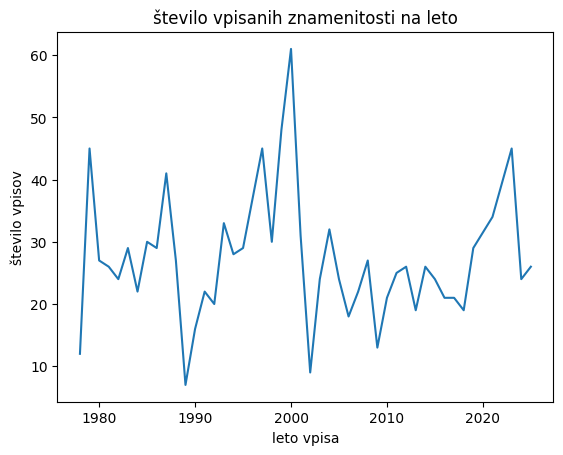

In [23]:
stevilo_vpisov.plot.line(ylabel="število vpisov", title="število vpisanih znamenitosti na leto")

Leta vpisov lahko uredimo tudi padajoče glede na število na novo vpisanih znamenitosti.

In [24]:
tabela.groupby("leto vpisa")["znamenitost"].count().sort_values(ascending=False)

leto vpisa
2000    61
1999    48
2023    45
1997    45
1979    45
        ..
1990    16
2009    13
1978    12
2002     9
1989     7
Name: znamenitost, Length: 46, dtype: int64

Največ jih je bilo vpisanih okoli leta 2000. Vidimo, da jih je bilo prvo leto res vpisanih precej malo.

## 5. Analiza po površini znamenitosti

In [25]:
tabela

,znamenitost,kategorija,drzave,kontinenti,leto vpisa,povrsina [ha],kriteriji
id,,,,,,,
211,Minaret and Archaeological Remains of Jam,cultural_danger,[Afghanistan],[Asia],2002,70,"[(ii, to exhibit an important interchange of h..."
208,Cultural Landscape and Archaeological Remains ...,cultural_danger,[Afghanistan],[Asia],2003,158.9265,"[(i, to represent a masterpiece of human creat..."
99,Natural and Cultural Heritage of the Ohrid region,mixed,"[Albania, North Macedonia]",[Europe],1979,94728.6,"[(i, to represent a masterpiece of human creat..."
570,Butrint,cultural,[Albania],[Europe],1992,ni podatka,"[(iii, to bear a unique or at least exceptiona..."
569,Historic Centres of Berat and Gjirokastra,cultural,[Albania],[Europe],2005,58.9,"[(iii, to bear a unique or at least exceptiona..."
...,...,...,...,...,...,...,...
509,Mosi-oa-Tunya / Victoria Falls,natural,"[Zambia, Zimbabwe]",[Africa],1989,6860,"[(vii, to contain superlative natural phenomen..."
302,"Mana Pools National Park, Sapi and Chewore Saf...",natural,[Zimbabwe],[Africa],1984,676600,"[(vii, to contain superlative natural phenomen..."
364,Great Zimbabwe National Monument,cultural,[Zimbabwe],[Africa],1986,722,"[(i, to represent a masterpiece of human creat..."


Iz tabele lahko izberemo le vrstice s podanim podatkom o površini in jih uredimo padajoče po površini.

In [26]:
tabela5 = tabela[tabela["povrsina [ha]"].str.contains(r'\d')].copy()
tabela5["povrsina [ha]"] = tabela5["povrsina [ha]"].apply(ast.literal_eval)
tabela5.sort_values(by="povrsina [ha]", ascending=False)

,znamenitost,kategorija,drzave,kontinenti,leto vpisa,povrsina [ha],kriteriji
id,,,,,,,
1603,French Austral Lands and Seas,natural,[France],[Europe],2019,1.662671e+08,"[(vii, to contain superlative natural phenomen..."
1325,Phoenix Islands Protected Area,natural,[Kiribati],[Oceania],2010,4.082500e+07,"[(vii, to contain superlative natural phenomen..."
1326,Papahānaumokuākea,mixed,[United States of America],[North America],2010,3.620750e+07,"[(iii, to bear a unique or at least exceptiona..."
154,Great Barrier Reef,natural,[Australia],[Oceania],1981,3.487000e+07,"[(vii, to contain superlative natural phenomen..."
1,Galápagos Islands,natural,[Ecuador],[South America],1978,1.406651e+07,"[(vii, to contain superlative natural phenomen..."
...,...,...,...,...,...,...,...
1569,The Maison Carrée of Nîmes,cultural,[France],[Europe],2023,4.740000e-02,"[(iv, to be an outstanding example of a type o..."
327,Quseir Amra,cultural,[Jordan],[Asia],1985,4.450000e-02,"[(i, to represent a masterpiece of human creat..."
44,Thracian Tomb of Kazanlak,cultural,[Bulgaria],[Europe],1979,1.550000e-02,"[(i, to represent a masterpiece of human creat..."


Kot bi pričakovali, so znamenitosti z največjo površino naravne ali mešane, z najmanj pa kulturne.

In [27]:
x = tabela5["povrsina [ha]"].mean()
print(f'{x:.2f}')

426372.41


Povprečna površina znamenitosti (s podanim podatkom) je nekaj več kot 400'000 ha.

In [28]:
x = tabela[tabela["povrsina [ha]"].str.contains(r'[a-z]')]['znamenitost'].count()
print(x)

118


Število znamenitosti brez podanega podatka o površini je 118, torej malo manj kot 10%.

Za vsako leto posebej lahko najdemo tudi povprečno površino tistega leta dodanih znamenitosti in jih uredimo naraščajoče.

In [29]:
tabela_5 = tabela5.groupby("leto vpisa")["povrsina [ha]"].mean()
tabela_5.sort_values()

leto vpisa
2015    2.222080e+04
1992    2.426336e+04
1993    2.521347e+04
1986    2.530164e+04
2021    3.439031e+04
            ...     
1982    7.485983e+05
1978    1.548538e+06
1981    1.962609e+06
2010    3.773616e+06
2019    5.807483e+06
Name: povrsina [ha], Length: 46, dtype: float64

Največjo povprečno površino imajo znamenitosti, dodane leta 2019, 2010 in okoli leta 1980, najmanjšo pa tiste v 2015.

Povprečno površino posameznega leta dodanih znamenitosti lahko predstavimo tudi s stolpičnim diagramom.

<Axes: title={'center': 'povprečna površina vpisanih znamenitosti po letih'}, xlabel='leto vpisa', ylabel='povprečna površina [ha] reda 10^6'>

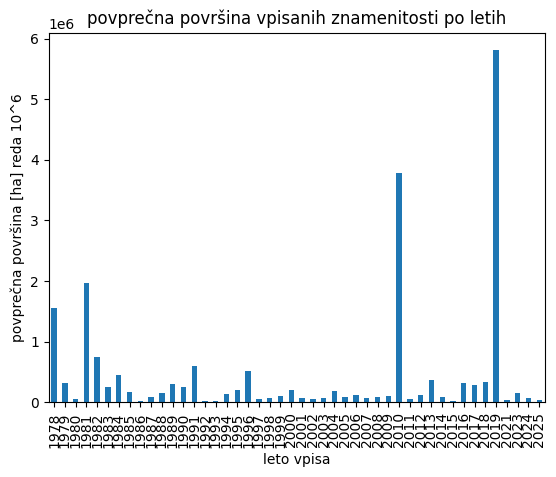

In [30]:
tabela_5.plot.bar(ylabel="povprečna površina [ha] reda 10^6", title="povprečna površina vpisanih znamenitosti po letih")

In [31]:
x = tabela5[tabela5["kategorija"] == "cultural"]["povrsina [ha]"].mean()
print(f'{x:.2f}')


8937.91


Povprečna površina kulturnih znamenitosti je malo manj kot 9'000 ha.

In [32]:
x = tabela5[tabela5["kategorija"] == "natural"]["povrsina [ha]"].mean()
print(f'{x:.2f}')

1777219.57


Povprečna površina naravnih znamenitosti pa je skoraj 1'800'000 ha, torej 200-krat večja od kulturnih.

## 6. Analiza po kriterijih

Tudi kriteriji so shranjeni v seznamih, zato jih najprej ločimo, da bo podan le eden na vrstico.

In [33]:
tabela6 = tabela.explode("kriteriji")
tabela6

,znamenitost,kategorija,drzave,kontinenti,leto vpisa,povrsina [ha],kriteriji
id,,,,,,,
211,Minaret and Archaeological Remains of Jam,cultural_danger,[Afghanistan],[Asia],2002,70,"(ii, to exhibit an important interchange of hu..."
211,Minaret and Archaeological Remains of Jam,cultural_danger,[Afghanistan],[Asia],2002,70,"(iii, to bear a unique or at least exceptional..."
211,Minaret and Archaeological Remains of Jam,cultural_danger,[Afghanistan],[Asia],2002,70,"(iv, to be an outstanding example of a type of..."
208,Cultural Landscape and Archaeological Remains ...,cultural_danger,[Afghanistan],[Asia],2003,158.9265,"(i, to represent a masterpiece of human creati..."
208,Cultural Landscape and Archaeological Remains ...,cultural_danger,[Afghanistan],[Asia],2003,158.9265,"(ii, to exhibit an important interchange of hu..."
...,...,...,...,...,...,...,...
365,Khami Ruins National Monument,cultural,[Zimbabwe],[Africa],1986,ni podatka,"(iii, to bear a unique or at least exceptional..."
365,Khami Ruins National Monument,cultural,[Zimbabwe],[Africa],1986,ni podatka,"(iv, to be an outstanding example of a type of..."
306,Matobo Hills,cultural,[Zimbabwe],[Africa],2003,205000,"(iii, to bear a unique or at least exceptional..."


In [34]:
tabela6.groupby("kriteriji")["znamenitost"].count().sort_values(ascending=False)

kriteriji
(iv, to be an outstanding example of a type of building, architectural or technological ensemble or landscape which illustrates (a) significant stage(s) in human history)                                                                                                                       648
(iii, to bear a unique or at least exceptional testimony to a cultural tradition or to a civilization which is living or which has disappeared)                                                                                                                                                  528
(ii, to exhibit an important interchange of human values, over a span of time or within a cultural area of the world, on developments in architecture or technology, monumental arts, town-planning or landscape design)                                                                         482
(i, to represent a masterpiece of human creative genius)                                                       

Največ znamenitosti izpolnjuje 4. kriterij, in sicer gradbeno ali arhitekturno prikazujejo pomembno obdobje v človeški zgodovini, sledijo pa še nadaljnji kriteriji o kulturni vrednosti, kar je pričakovano glede na to, da je na seznamu Unesca največ znamenitosti kulturnih. Najmanj znamenitosti pa po drugi strani izpolnjuje 8. kriterij, torej je najmanj znamenitosti primerov pomembnih obdobij v zgodovini Zemlje.

Tudi za posamezne znamenitosti lahko ugotovimo, koliko kriterijev izpolnjujejo. Nato jih uredimo padajoče.

In [35]:
tabela6.groupby("znamenitost")["kriteriji"].count().sort_values(ascending=False)

znamenitost
Mount Taishan                                                             7
Tasmanian Wilderness                                                      7
Mogao Caves                                                               6
Mount Athos                                                               6
Ancient Maya City and Protected Tropical Forests of Calakmul, Campeche    6
                                                                         ..
Wadi Al-Hitan (Whale Valley)                                              1
Walled City of Baku with the Shirvanshah's Palace and Maiden Tower        1
Western Tien-Shan                                                         1
Whale Sanctuary of El Vizcaino                                            1
Wieliczka and Bochnia Royal Salt Mines                                    1
Name: kriteriji, Length: 1248, dtype: int64

Največ kriterijev (7 od 10) izpolnjujeta gora Taishan in tasmanska divjina. Vidimo tudi, da veliko znamenitosti izpoljuje le 1 kriterij.

Ugotovimo lahko tudi skupno število kriterijev, ki jih izpolnjuje posamezna kategorija znamenitosti, in število znamenitosti po kategorijah, iz česar lahko izračunamo povprečno število izpolnjenih kriterijev glede na kategorijo.

In [36]:
tabela7 = tabela6.groupby("kategorija").agg({"kriteriji": "count", "znamenitost": "nunique"}).sort_values(by="kriteriji", ascending=False)
tabela7

,kriteriji,znamenitost
kategorija,,
cultural,2163,933
natural,452,221
mixed,165,41
cultural_danger,107,39
natural_danger,32,14


Ni presenetljivo, da največ kriterijev izpolnjuje kulturna kategorija, ki tudi obsega največ znamenitosti, najmanj pa ogrožene naravne znamenitosti, ki jih je tudi najmanj.

In [37]:
tabela8 = (tabela7["kriteriji"] / tabela7["znamenitost"])
tabela8.sort_values(ascending=False)

kategorija
mixed              4.024390
cultural_danger    2.743590
cultural           2.318328
natural_danger     2.285714
natural            2.045249
dtype: float64

V povprečju pa največ kriterijev, in sicer 4 od 10, izpolnjuje kategorija mešanih znamenitosti, torej tistih, ki so pomembne tako naravno kot kulturno, kar je pričakovano. Najmanj kriterijev pa v povprečju izpolnjujejo naravne znamenitosti, in sicer 2 od 10.

Podatke o tako številu izpolnjenih kriterijev kot številu znamenitosti po kategorijah lahko predstavimo s stolpičnim diagramom.

<Axes: title={'center': 'število izpolnjenih kriterijev in število znamenitosti po kategorijah'}, xlabel='kategorija'>

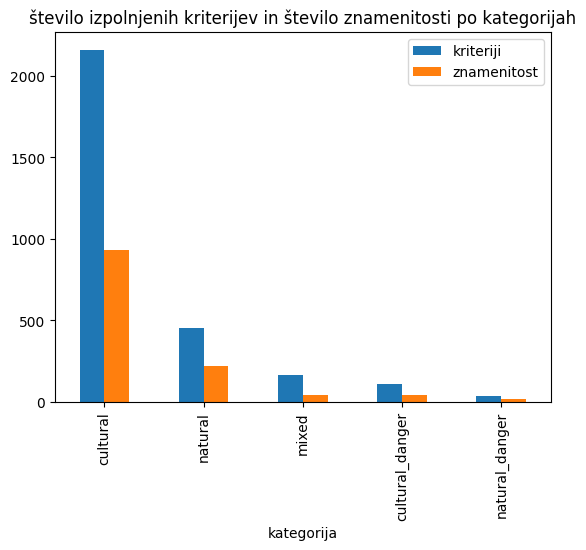

In [38]:
tabela7.plot.bar(title="število izpolnjenih kriterijev in število znamenitosti po kategorijah")